In [10]:
from Creador import generar_instancia_irp  # Asegúrate de usar el nombre del archivo correcto
from Instancia import Instancia
from Proceso import Proceso
from Politica import PoliticaSimple, PoliticaSimpleClusterisada, RollOutSimple, RollOutCluster, MonteCarlo
from FuncionesAuxiliares import kmeans_clustering, visualizar_clusters, kmeans_clustering_sklearn
import numpy as np
import os
from Generador_de_instancias import n_instancias, generar_instancias, semillas
from Simulacion import Simulacion
from Resultados import Resultados
import matplotlib.pyplot as plt

In [11]:
#generar_instancias(semillas=semillas)

In [3]:
# Parámetros de la simulación
#carpeta_instancias = "INSTANCIAS FREE"
#n_repeticiones = 1

# Ejecutar la simulación
#simulacion = Simulacion(carpeta_instancias, n_instancias, n_repeticiones)
#resultados = simulacion.ejecutar()

In [4]:
resultados = Resultados( nombre_archivo= 'resultadosPoliticasSimpleYCluster.xlsx')

resultados = resultados.leer_archivo()

In [5]:
resultados['Costo Traslado Simple'].mean()

np.float64(0.41586459029561046)

In [6]:
resultados['Costo Traslado Clusterizado'].mean()

np.float64(0.29877567857657605)

In [7]:
resultados['Costo Total Simple'].mean()

np.float64(1897.5383064862312)

In [8]:
resultados['Costo Total Clusterizado'].mean()

np.float64(2179.073354747131)

In [9]:
resultados['Costo total Rollout Simple'].mean()

np.float64(1284.783988673995)

In [10]:
resultados['Costo total RollOut Clusterizado'].mean()

np.float64(1139.2834645673354)

# Preguntar sobre la lognormal, ya que son las velocidades de los vehículos

# Creador de los archivos XML que contienen las instancias

# ejecutamos las políticas

# EJECUCIÓN DE INSTANCIA DE EJEMPLO

In [ ]:
# Generar instancia (ARCHIVO XML)
mensaje = generar_instancia_irp(
        ancho_zona = 50, # 20 km radio de la zona
        largo_zona = 50, # 20 km radio de la zona
        horizonte_tiempo = 300,
        num_productos =3,
        num_clientes = 18, #4
        num_vehiculos = 4, #2
        semilla = 5, # la 5 es para explicar facil 
        nombre_archivo= 'instanciaEjemplo2.xml'
    )

In [13]:
carpeta_instancias = "INSTANCIAS MC"
ruta_completa = os.path.join(carpeta_instancias, f'instanciaEjemplo2.xml')
# Lectura de la instancia y se guarda en un objeto instancia
instancia = Instancia(ruta_archivo=ruta_completa, umbral_inventario_clientes= 0.3, umbral_inventario_vehiculos= 0.3)
# Se genera el proceso mediante la instancia
proceso = Proceso(instancia)
politicaSimple = PoliticaSimple(instancia,proceso)
politicaClusterisada = PoliticaSimpleClusterisada(instancia,proceso)

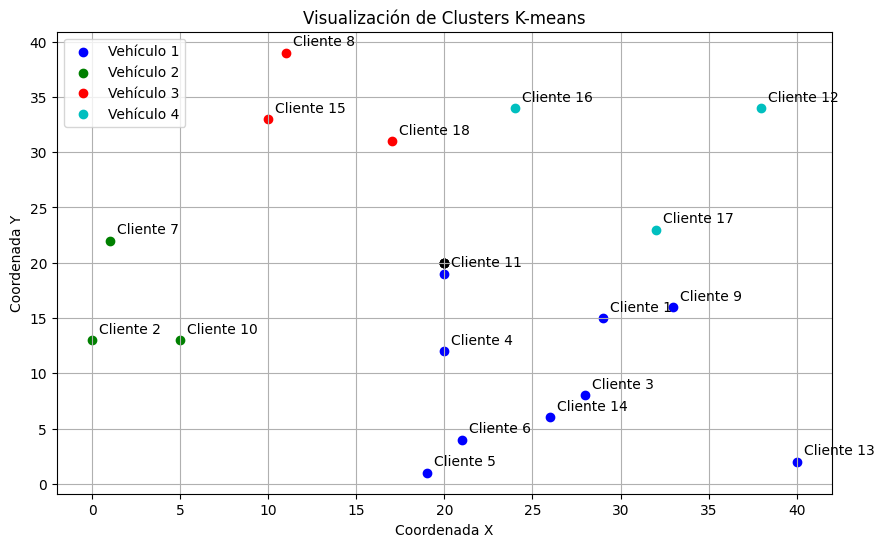

In [14]:
# Inicializamos el númmero de clusters
M = len(instancia.vehiculos.keys())
#Obtenemos las posiciones de los clientes
posiciones_clientes = { idc: {'x':cliente.posicion_x, 'y': cliente.posicion_y} for idc, cliente in instancia.clientes.items()}

# Ejecutar k-means (usando la función anterior)
clusters = kmeans_clustering_sklearn(M, posiciones_clientes)

# Visualizar resultados
visualizar_clusters(posiciones_clientes, clusters, {'x': instancia.depot_X, 'y': instancia.depot_Y})

In [15]:
print(f'los vehiculos son: \n {instancia.vehiculos}')
print(f'los clientes son:  \n {instancia.clientes}')
print(f'los productos son : \n {instancia.productos}')
print(f'las demandas medias son: {instancia.demandas_medias}')
print(instancia.depot_X)
print(instancia.depot_Y)

los vehiculos son: 
 {1: Vehiculo(id=1, capacidad=400.0, velocidad_media=3.0, desv_est_velocidad=0.4, inventario={1: 129, 2: 139, 3: 129}), 2: Vehiculo(id=2, capacidad=400.0, velocidad_media=3.0, desv_est_velocidad=0.4, inventario={1: 129, 2: 139, 3: 129}), 3: Vehiculo(id=3, capacidad=400.0, velocidad_media=3.0, desv_est_velocidad=0.4, inventario={1: 129, 2: 139, 3: 129}), 4: Vehiculo(id=4, capacidad=400.0, velocidad_media=3.0, desv_est_velocidad=0.4, inventario={1: 129, 2: 139, 3: 129})}
los clientes son:  
 {1: Cliente(id=1, posicion_x=29.0, posicion_y=15.0, capacidad_almacenamiento=132.0, inventarios_iniciales={1: 0.0, 2: 0.0, 3: 0.0}, costos_inventario={1: 0.0, 2: 0.0, 3: 0.0}, costos_penalizacion={1: 2.0, 2: 1.0, 3: 2.0}, demanda_media={1: 2.0, 2: 3.0, 3: 1.0}, demanda_desv_est={1: 1.23, 2: 1.49, 3: 2.15}), 2: Cliente(id=2, posicion_x=0.0, posicion_y=13.0, capacidad_almacenamiento=120.0, inventarios_iniciales={1: 0.0, 2: 0.0, 3: 0.0}, costos_inventario={1: 0.0, 2: 0.0, 3: 0.0}, co

# Política simple

In [16]:
costos = np.array([])
traslado = np.array([])
n=100
for _ in range(n):

    trayectoriaSimple, costo_traslado , _ = politicaSimple.run()  
    traslado  =  np.append(traslado,costo_traslado)
    #for estado_accion in trayectoriaSimple:
        #print(estado_accion['estado'])
        #print(estado_accion['accion'])
    costo =sum(estado_accion['recompensa'] for estado_accion in trayectoriaSimple)

    costos = np.append(costos,costo)
promedio_simple = np.mean(costos)
trasladdo_promedio = np.mean(traslado)
print(promedio_simple)
print(trasladdo_promedio)

for t in trayectoriaSimple:
    print(t['estado'])
    print(t['accion'])

56890.84519892515
0.03628981318292085

    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 0.0, 2: 0.0, 3: 0.0}, 2: {1: 0.0, 2: 0.0, 3: 0.0}, 3: {1: 0.0, 2: 0.0, 3: 0.0}, 4: {1: 0.0, 2: 0.0, 3: 0.0}, 5: {1: 0.0, 2: 0.0, 3: 0.0}, 6: {1: 0.0, 2: 0.0, 3: 0.0}, 7: {1: 0.0, 2: 0.0, 3: 0.0}, 8: {1: 0.0, 2: 0.0, 3: 0.0}, 9: {1: 0.0, 2: 0.0, 3: 0.0}, 10: {1: 0.0, 2: 0.0, 3: 0.0}, 11: {1: 0.0, 2: 0.0, 3: 0.0}, 12: {1: 0.0, 2: 0.0, 3: 0.0}, 13: {1: 0.0, 2: 0.0, 3: 0.0}, 14: {1: 0.0, 2: 0.0, 3: 0.0}, 15: {1: 0.0, 2: 0.0, 3: 0.0}, 16: {1: 0.0, 2: 0.0, 3: 0.0}, 17: {1: 0.0, 2: 0.0, 3: 0.0}, 18: {1: 0.0, 2: 0.0, 3: 0.0}}
        Inventarios de vehículos: 
        {1: {1: 129, 2: 139, 3: 129}, 2: {1: 129, 2: 139, 3: 129}, 3: {1: 129, 2: 139, 3: 129}, 4: {1: 129, 2: 139, 3: 129}}
        Planificación de entregas:
        {1: {}, 2: {}, 3: {}, 4: {}}
        Tiempo transcurrido: 0.00 unidades de tiempo
        Posiciones de vehículos:
        {1: {'x': 20.0, 'y': 20.0}, 2: {'x': 

# Instancia Clusterizada

In [17]:
#trayectoriaClusterisada,costo_traslado ,_ = politicaClusterisada.run()
#print(costo_traslado)
#sum( estado_accion['recompensa'] for estado_accion in trayectoriaClusterisada)

costos = np.array([])
n=100
for _ in range(n):
    trayectoriaSimple, costo_traslado , _ = politicaClusterisada.run()
    #for estado_accion in trayectoriaSimple:
        #print(estado_accion['estado'])
        #print(estado_accion['accion'])
    costo =sum(estado_accion['recompensa'] for estado_accion in trayectoriaSimple)
    costos = np.append(costos,costo)
promedio_cluster = np.mean(costos)
promedio_cluster

np.float64(56111.74946311569)

# Implementamos la Rollout Simple ahora

In [18]:
PoliticaRollout = RollOutSimple(instancia= instancia, proceso= proceso)
'''
trayectoria_rollout_simple,_,_ = PoliticaRollout.run()

#for i in trayectoria_rollout_simple:
 #   print(i['estado'])
  #  print(i['accion'])
sum(i['recompensa'] for i in trayectoria_rollout_simple)
'''
costos = np.array([])

# ejecutamos 10 veces la política rollout
for _ in range(2):
    trayectoria_rollout,_,_ = PoliticaRollout.run()
    costo_episodio =  sum(i['recompensa'] for i in trayectoria_rollout)
    costos = np.append(costos,costo_episodio)

promedio_costo_rollout_simple = np.mean(costos)
print(promedio_costo_rollout_simple)

53813.28350394851


# Ahora implementamos la RollOut clusterizada

In [19]:
PoliticaRolloutCluster = RollOutCluster( instancia= instancia, proceso= proceso)

costos = np.array([])
# ejecutamos 10 veces la política rollout cluster
for _ in range(5):
    trayectoria_rollout_cluster,_,_ = PoliticaRolloutCluster.run()
    costos = np.append(costos, sum( i['recompensa'] for i in trayectoria_rollout_cluster))
promedio_costo_rollout_cluster = np.mean(costos)
print(promedio_costo_rollout_cluster)

53701.48488178556


# implementamos la política MC OnPolicy

In [ ]:
MC = MonteCarlo(instancia = instancia, proceso = proceso, episodios = 5000, epsilon=0.01, learning_rate=0.001) # para que converja debe estar en 10^-6  episodios = 10000, epsilon=0.3, learning_rate=0.00001) Esta da bien

In [ ]:
MC.entrenar_modelo()

In [ ]:
trayectoria_MC, traslado = MC.ejecutar_politica_mejores_betas()
print(traslado)
sum( i['recompensa'] for i in trayectoria_MC)

2321.6266994435555


np.float64(101176.62669944359)

In [17]:
for t in trayectoria_MC:
    print(t['estado'])
    print(t['accion'])


    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 0.0, 2: 0.0}, 2: {1: 0.0, 2: 0.0}, 3: {1: 0.0, 2: 0.0}, 4: {1: 0.0, 2: 0.0}, 5: {1: 0.0, 2: 0.0}, 6: {1: 0.0, 2: 0.0}, 7: {1: 0.0, 2: 0.0}, 8: {1: 0.0, 2: 0.0}, 9: {1: 0.0, 2: 0.0}, 10: {1: 0.0, 2: 0.0}, 11: {1: 0.0, 2: 0.0}, 12: {1: 0.0, 2: 0.0}}
        Inventarios de vehículos: 
        {1: {1: 186, 2: 212}, 2: {1: 186, 2: 212}, 3: {1: 186, 2: 212}}
        Planificación de entregas:
        {1: {}, 2: {}, 3: {}}
        Tiempo transcurrido: 0.00 unidades de tiempo
        Posiciones de vehículos:
        {1: {'x': 20.0, 'y': 20.0}, 2: {'x': 20.0, 'y': 20.0}, 3: {'x': 20.0, 'y': 20.0}}
        
{2: {1: {1: 186, 2: 149}}}

    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 0, 2: 0}, 2: {1: 0, 2: 0}, 3: {1: 0, 2: 0}, 4: {1: 0, 2: 0}, 5: {1: 0, 2: 0}, 6: {1: 0, 2: 0}, 7: {1: 0, 2: 0}, 8: {1: 0, 2: 0}, 9: {1: 0, 2: 0}, 10: {1: 0, 2: 0}, 11: {1: 0, 2: 0}, 12: {1: 0, 2: 0}}
        Inventario

In [64]:
print(promedio_simple)
print(promedio_cluster)
print(promedio_costo_rollout_simple)
print(promedio_costo_rollout_cluster)
print(MC.registro_optimos_mejores_betas)

69124.01085789873
65315.52850605881
65429.15457049584
65696.54827406176
[87159.9        83881.61185805 83881.61185805 83881.61185805
 83881.61185805 83881.61185805 83858.32903407 83858.32903407
 83853.20616113 83853.20616113 83853.20616113 82806.4761572
 82806.4761572  82806.4761572  70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.38890538 70977.38890538 70977.38890538 70977.38890538
 70977.3889053

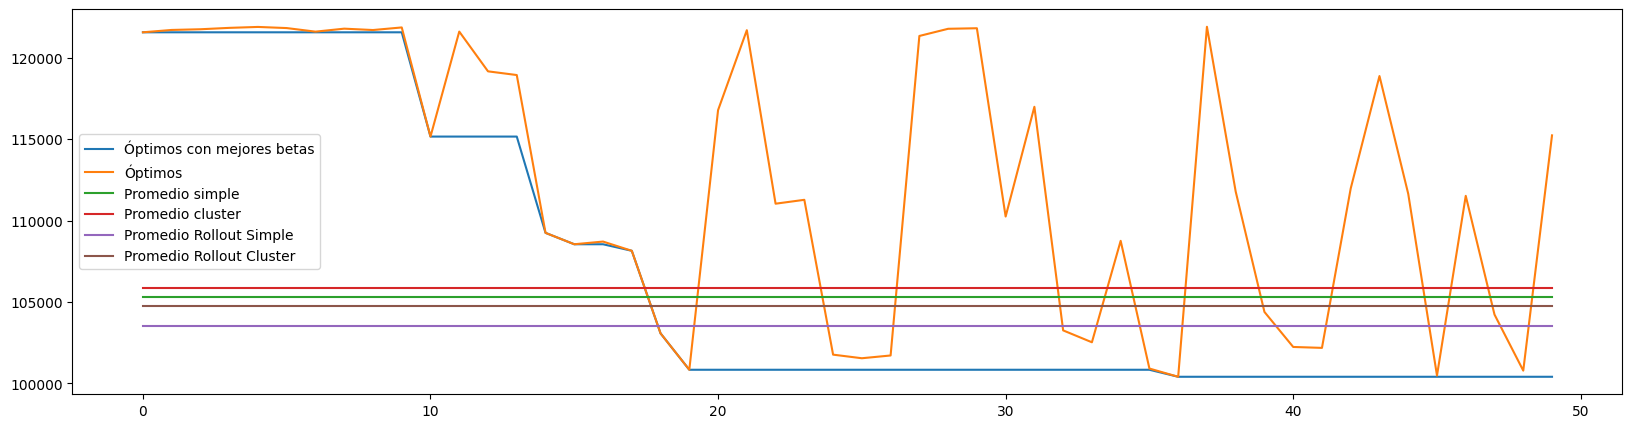

In [14]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(20,5))
plt.plot(MC.registro_optimos_mejores_betas, label='Óptimos con mejores betas')
plt.plot(MC.registro_optimos, label='Óptimos')
plt.plot([promedio_simple for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio cluster')
plt.plot([promedio_costo_rollout_simple for _ in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Simple')
plt.plot([promedio_costo_rollout_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Cluster')

plt.legend() # Esto muestra las leyendas en el gráfico
plt.show()

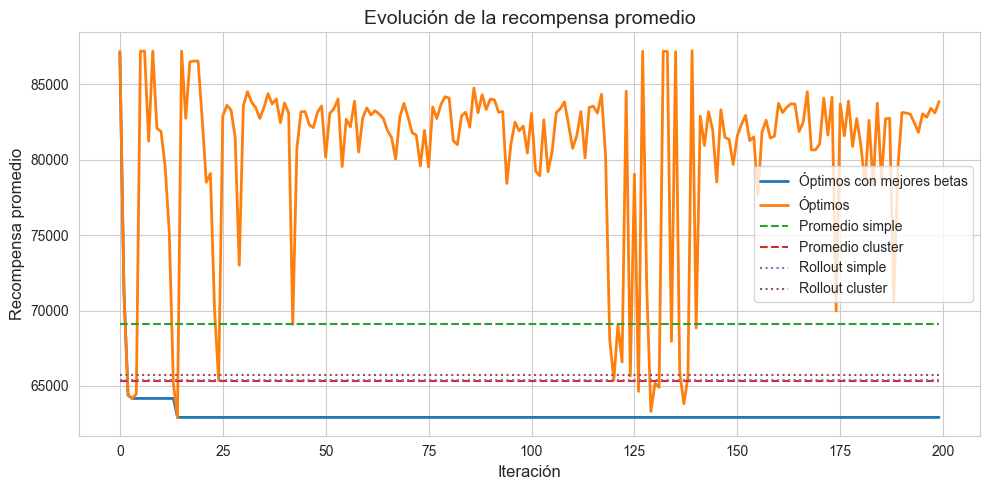

In [57]:
import seaborn as sns

# Estilo académico
sns.set_style(style='whitegrid')
plt.figure(figsize=(10, 5))

# Línea de datos
plt.plot(MC.registro_optimos_mejores_betas, label='Óptimos con mejores betas', linewidth=2)
plt.plot(MC.registro_optimos, label='Óptimos', linewidth=2)
plt.plot([promedio_simple] * len(MC.registro_optimos_mejores_betas), label='Promedio simple', linestyle='--', linewidth=1.5)
plt.plot([promedio_cluster] * len(MC.registro_optimos_mejores_betas), label='Promedio cluster', linestyle='--', linewidth=1.5)
plt.plot([promedio_costo_rollout_simple] * len(MC.registro_optimos_mejores_betas), label='Rollout simple', linestyle=':', linewidth=1.5)
plt.plot([promedio_costo_rollout_cluster] * len(MC.registro_optimos_mejores_betas), label='Rollout cluster', linestyle=':', linewidth=1.5)

# Mejoras visuales
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Recompensa promedio', fontsize=12)
plt.title('Evolución de la recompensa promedio', fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout()

# Guardar en alta resolución si lo necesitas
# plt.savefig('grafico_recompensas.pdf', dpi=300)

plt.show()

In [15]:
costos = np.array([])
n=100
for _ in range(n):
    trayectoriaSimple, costo_traslado = MC.ejecutar_politica_mejores_betas()
    #for estado_accion in trayectoriaSimple:
        #print(estado_accion['estado'])
        #print(estado_accion['accion'])
    costo =sum(estado_accion['recompensa'] for estado_accion in trayectoriaSimple)
    costos = np.append(costos,costo)
promedio = np.mean(costos)
promedio

np.float64(100872.65156485132)

# Ejemplo de lo que hace la planificación segun el inventario del vehículo y las demandas del cliente 

In [33]:
def planificar_entrega(inventario, demandas):
    """
    Calcula un plan de entrega de productos basado en la disponibilidad del inventario y la demanda relativa de cada producto.
    
    La función distribuye el inventario total de manera proporcional a la demanda esperada de cada producto.
    
    Parámetros:
    - inventario (dict): Diccionario donde las claves son los IDs de los productos y los valores la cantidad disponible en el vehículo.
    - demandas (dict): Diccionario donde las claves son los IDs de los productos y los valores representan la demanda promedio esperada.
    
    Retorna:
    - dict: Un diccionario con la planificación de entrega de cada producto basada en la disponibilidad y la proporción de demanda.
    """
    planificacion = {}
    
    # Calcular la demanda total esperada y el total de inventario disponible
    total_demanda = sum(demandas.values())
    total_inventario = sum(inventario.values())
    
    # Si no hay demanda o inventario, se retorna una planificación con entrega 0 para todos los productos
    if total_demanda == 0 or total_inventario == 0:
        return {producto: 0 for producto in demandas}
    
    # Distribuir el inventario proporcionalmente según la demanda de cada producto
    for producto, demanda in demandas.items():
        ponderador = demanda / total_demanda  # Proporción de la demanda respecto a la demanda total
        entrega = round(ponderador * total_inventario)  # Cantidad a entregar basada en la proporción
        disponible = inventario.get(producto, 0)  # Obtener la cantidad disponible en inventario
        planificacion[producto] = min(entrega, disponible)  # No entregar más de lo disponible
        
        # Reducir el inventario según lo entregado
        inventario[producto] = max(0, disponible - planificacion[producto])
    
    return planificacion

# Ejemplos de uso

# Caso 1: Inventario suficiente para cumplir la proporción exacta
inventario = {0: 1, 1: 1, 2: 5}
demandas = {0: 2, 1: 4, 2: 6}
print(planificar_entrega(inventario, demandas))  # Salida esperada: {0: 3, 1: 7, 2: 10}

# Caso 2: Inventario limitado, debe ajustarse a la proporción
inventario = {0: 5, 1: 5, 2: 5}
demandas = {0: 2, 1: 4, 2: 6}
print(planificar_entrega(inventario, demandas))  # Salida esperada: {0: 1, 1: 2, 2: 2}

# Caso 3: Un producto sin demanda
inventario = {0: 10, 1: 10, 2: 10}
demandas = {0: 0, 1: 4, 2: 6}
print(planificar_entrega(inventario, demandas))  # Salida esperada: {0: 0, 1: 4, 2: 6}

# Caso 4: Sin inventario disponible
inventario = {0: 0, 1: 0, 2: 0}
demandas = {0: 2, 1: 4, 2: 6}
print(planificar_entrega(inventario, demandas))  # Salida esperada: {0: 0, 1: 0, 2: 0}

# Caso 5: Sin demanda de ningún producto
inventario = {0: 10, 1: 10, 2: 10}
demandas = {0: 0, 1: 0, 2: 0}
print(planificar_entrega(inventario, demandas))  # Salida esperada: {0: 0, 1: 0, 2: 0}

{0: 1, 1: 1, 2: 4}
{0: 2, 1: 5, 2: 5}
{0: 0, 1: 10, 2: 10}
{0: 0, 1: 0, 2: 0}
{0: 0, 1: 0, 2: 0}


In [22]:
a = {1 : {12:1, 2:30}, 2: {1:20, 3:30}}

In [5]:
next(iter(a.values()))

{12: 1, 2: 30}